In [64]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [65]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [66]:
# determine the number of rows that have HourlyVisibility values > 16 to check
CV_rows_hv16 = CV_rows[CV_rows['HourlyVisibility'] > 16]

print(f"Number of rows with HourlyVisibility > 16: {len(CV_rows_hv16)}")

Number of rows with HourlyVisibility > 16: 0


In [67]:
# filtering visibility threshold to identify nan values
CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17]

# print to see the difference
print("CV_rows:", CV_rows.shape)
print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_rows: (8221094, 18)
CV_filtered_rows: (8221094, 18)


In [68]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

# print to see length after removing April-October
print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (3634348, 18)


In [69]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [70]:
# Find stations with data back to at least 1975
stations_pre1975 = (
    # use station-years from CV_rows
    CV_rows.groupby('STATION')['year']
    # find minimum year for each station
    .min()
    # filter to stations with minimum year <= 1975
    .loc[lambda s: s <= 1975]
    # get the station names as a list
    .index
    # convert to list
    .tolist()
)

print(len(stations_pre1975), "stations with data back to at least 1975")
print(stations_pre1975)

# make dateframe with station locations
station_locations = (
    # use CV_rows to get stations with data back to at least 1975
    CV_rows[CV_rows['STATION'].isin(stations_pre1975)]
    # drop duplicate stations to get unique locations
    .drop_duplicates(subset=['STATION'])
    # select only the columns we want
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    # reset the index to get a clean dataframe
    .reset_index(drop=True)
)

13 stations with data back to at least 1975
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'FRESNO YOSEMITE INTL', 'LEMOORE REEVES NAS', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB']


In [71]:
# count the number of years of data for each station
station_year_counts = (
    # From CV_rows
    CV_rows
    # drop duplicate years for each station
    .drop_duplicates(subset=['STATION', 'year'])
    # group by station 
    .groupby('STATION')['year']
    # count the number of unique years for each station
    .nunique()
    # sort the counts in descending order
    .sort_values(ascending=False)
)

# make a list of stations with more than 30 years of data
# then filter that list to only include stations with data back to at least 1975
stations_30_years = station_year_counts[station_year_counts > 25].index.tolist()
# filter to stations with data back to at least 1975
stations_30_years_pre1975 = [s for s in stations_30_years if s in stations_pre1975]

# print the number of stations with more than 25 years of data
print(len(stations_30_years), "stations with more than 25 years of data")
# print the list of stations with data back to at least 1975
print("stations_30_years_pre1975:", stations_30_years_pre1975)
station_year_counts.loc[stations_30_years_pre1975]

14 stations with more than 25 years of data
stations_30_years_pre1975: ['BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'RED BLUFF MUNI AP', 'FRESNO YOSEMITE INTL', 'TRAVIS FIELD AFB', 'SACRAMENTO MATHER AFB', 'STOCKTON AP', 'SACRAMENTO MCCLELLAN AFB', 'CASTLE AFB', 'LEMOORE REEVES NAS', 'BEALE AFB', 'REDDING AP', 'SACRAMENTO METROPOLITAN AP']


STATION
BAKERSFIELD AP                99
SACRAMENTO AP ASOS            96
RED BLUFF MUNI AP             86
FRESNO YOSEMITE INTL          83
TRAVIS FIELD AFB              78
SACRAMENTO MATHER AFB         78
STOCKTON AP                   76
SACRAMENTO MCCLELLAN AFB      73
CASTLE AFB                    67
LEMOORE REEVES NAS            66
BEALE AFB                     62
REDDING AP                    55
SACRAMENTO METROPOLITAN AP    52
Name: year, dtype: int64

In [72]:
# Remove stations with 149 or fewer days counted per year
filtered_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 149].copy()

# Get the valid station-year combinations for merging,
# meaning those that have more than 149 days counted
valid_station_years = filtered_days_year_no_outliers[["STATION", "year"]]
CV_filtered_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", filtered_days_year_no_outliers.shape[0])
print("CV_filtered_rows_no_outliers:", CV_filtered_rows_no_outliers.shape)

Station-years kept: 767
CV_filtered_rows_no_outliers: (3173543, 18)


In [73]:
# Filter rows from the narrowed dataframe for fog
# For hourly visibility less than 0.403 miles and hourly precipitation less than 0.03 mm
low_vis_rows = CV_filtered_rows_no_outliers[
    (CV_filtered_rows_no_outliers["HourlyVisibility"] < 0.403)
    & (CV_filtered_rows_no_outliers["HourlyPrecipitation"] < 0.03)
]

# For hourly visibility less than 1.000 miles and hourly precipitation less than 0.03 mm
low_vis_rows_1km = CV_filtered_rows_no_outliers[
   (CV_filtered_rows_no_outliers["HourlyVisibility"] < 1.000)
    & (CV_filtered_rows_no_outliers["HourlyPrecipitation"] < 0.03)
]


print("CV_filtered_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
print("CV_filtered_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows_1km.shape)

CV_filtered_rows_no_outliers with HourlyVisibility < 0.403: (123458, 18)
CV_filtered_rows_no_outliers with HourlyVisibility < 1.000: (165397, 18)


In [74]:
# Drop duplicates
low_vis_rows = low_vis_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'hour'])
low_vis_rows_1km = low_vis_rows_1km.drop_duplicates(subset=['STATION', 'year', 'month', 'hour'])

print(low_vis_rows.shape)
print(low_vis_rows_1km.shape)

(33881, 18)
(38722, 18)


In [75]:
# add a new dataframe to count the number of low visibility days per year per station
# with year, month, and day as unique identifiers to avoid double counting
# determine the number of fog days per year per station
fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)
# determine the number of fog days per year per station for visibility < 1.000 km
fog_days_year_1km = (
    low_vis_rows_1km
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [76]:
# print the number of unique years for each station in fog_days_year
station_year_counts = fog_days_year.groupby("STATION")["year"].nunique()
# print the number of stations with at least 30 years of fog data
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter fog_days_year to only include stations with at least 30 years of data
fog_days_year_filtered = fog_days_year[
    fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# filter fog_days_year_1km to only include stations with at least 30 years of data
fog_days_year_filtered_1km = fog_days_year_1km[
    fog_days_year_1km["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered fog_days_year rows:", fog_days_year_filtered.shape)
print("Filtered fog_days_year_1km rows:", fog_days_year_filtered_1km.shape)

Stations kept: 13
Filtered fog_days_year rows: (742, 3)
Filtered fog_days_year_1km rows: (742, 3)


In [77]:
# see the first few rows of low visibility data
low_vis_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,MonthlyNumberDaysWithHeavyFog,year,month,day,hour,minute,STATION
124,USW00093193,36.78,-119.7194,1942-01-06 04:00:00,SAO,0.8,0.8,0.0,0.2,0.0,0.0,NaN,1942,1,6,4,0,FRESNO YOSEMITE INTL
125,USW00093193,36.78,-119.7194,1942-01-06 05:00:00,SAO,0.8,0.8,0.0,0.2,0.0,0.0,NaN,1942,1,6,5,0,FRESNO YOSEMITE INTL
126,USW00093193,36.78,-119.7194,1942-01-06 06:00:00,SAO,0.2,0.2,0.0,0.2,0.0,0.0,NaN,1942,1,6,6,0,FRESNO YOSEMITE INTL
127,USW00093193,36.78,-119.7194,1942-01-06 07:00:00,SAO,-0.4,-0.4,0.0,0.2,0.0,0.0,NaN,1942,1,6,7,0,FRESNO YOSEMITE INTL
199,USW00093193,36.78,-119.7194,1942-01-09 08:00:00,SAO,8.5,9.1,0.0,0.4,315.0,1.0,NaN,1942,1,9,8,0,FRESNO YOSEMITE INTL


In [78]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if low_vis_events["DATE"].dtype == object:
    # convert DATE to datetime
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

# sort by station and date
low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    # convert DATE to datetime
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
# below we timedelta999 is used to fill in the first observation's time_diff, which is NaN, with a large value to ensure it starts a new event
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
# below we identify new low-visibility fog events based on a 2.5-hour gap
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=2.5)
# then we assign an event_id to each low-visibility fog event by cumulatively summing the new_event flags within each station
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

# compute summary statistics for each low-visibility fog event
# including start and end times, year, month, and duration in hours
event_summary = (
    low_vis_events
    # group by station and event_id to compute summary statistics for each event
    .groupby(["STATION", "event_id"], as_index=False)
    # aggregate to compute start, end, year, month, and duration in hours for each event
    .agg(
        # compute start and end times, year, month, and duration in hours for each event
        start=("DATE", "min"),
        end=("DATE", "max"),
        # compute year and month from the start time of the event
        year=("year", "first"),
        month=("month", "first"),
        # compute duration in hours for each event
        duration_hours=("event_id", "size"),
    )
)

# compute year_month for event_summary, which will be used for monthly aggregation
event_summary["year_month"] = pd.to_datetime(
    # create a datetime object from the year and month of each event, setting day to 1
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

# compute the number of low visibility days per month per station
monthly_low_vis_days = (
    # start with
    low_vis_events
    # drop duplicate days to avoid double counting
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    # group by station, year, and month to count the number of low visibility days
    .groupby(["STATION", "year", "month"], as_index=False)
    # count the number of low visibility days per month per station
    .size()
    # rename the size column to low_vis_days for clarity
    .rename(columns={"size": "low_vis_days"})
)

# compute monthly statistics for low-visibility fog events,
# including average duration and number of events, and merge with monthly low visibility days
event_monthly = (
    # compute monthly statistics for low-visibility fog events
    event_summary
    # group by station, year, and month to compute average duration and number of events
    .groupby(["STATION", "year", "month"], as_index=False)
    # aggregate to compute average duration and number of events
    .agg(
        # compute average duration and number of events
        avg_event_duration_hours=("duration_hours", "mean"),
        # compute number of events
        n_events=("duration_hours", "size"),
    )
    # merge with monthly low visibility days to include the count of low visibility days for each month
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

# compute year_month for event_monthly, which will be used for annual aggregation
event_monthly["year_month"] = pd.to_datetime(
    # create a datetime object from the year and month of each event, setting day to 1
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

# compute annual statistics for low-visibility fog events,
# including average duration, total number of events, and average monthly low visibility days
annual_event_stats = (
    # starting from event_monthly
    event_monthly
    # group by station and year to compute annual statistics
    .groupby(["STATION", "year"], as_index=False)
    # aggregate to compute average duration
    # total number of events, and average monthly low visibility days
    .agg(
        # compute average duration, total number of events, and average monthly low visibility days
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        # compute total number of events
        total_events=("n_events", "sum"),
        # compute average monthly low visibility days
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

# merge annual_event_stats with fog_days_year_filtered
# to compare the number of fog days with the number of events
annual_compare = fog_days_year_filtered.merge(
    # merge with annual_event_stats to compare the number of fog days with the number of events
    annual_event_stats,
    # merge on station and year to align the data correctly
    on=["STATION", "year"],
    # use a left join to keep all rows from fog_days_year_filtered
    # and add matching rows from annual_event_stats
    how="left"
)

# print the first few rows of annual_compare to check the results
print(annual_compare.head())

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932         9                  2.250000            11   
1  BAKERSFIELD AP  1933         9                  3.100000            12   
2  BAKERSFIELD AP  1934        19                  4.347222            21   
3  BAKERSFIELD AP  1935        13                  2.050000            12   
4  BAKERSFIELD AP  1936        10                  2.083333            13   

   avg_monthly_low_vis_days  
0                      3.00  
1                      3.00  
2                      4.75  
3                      3.25  
4                      2.50  


In [79]:
# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    # if wind direction is 0 or NaN
    wd.eq(0) | wd.isna(),
    # set north-south component to
    0.0,
    # compute the north-south component using cosine of wind direction in radians
    np.cos(np.deg2rad(wd))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    # if wind direction is 0 or NaN
    wd.eq(0) | wd.isna(),
    # set west-east component to
    0.0,
    # compute the west-east component using sine of wind direction in radians
    np.sin(np.deg2rad(wd))
)

# print the first few rows of CV_rows to check the new wind components
CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
0,315.0,0.707107,-0.707107
1,315.0,0.707107,-0.707107
2,315.0,0.707107,-0.707107
3,315.0,0.707107,-0.707107
4,315.0,0.707107,-0.707107


Total station-component trends tested: 28
Significant trends (p < 0.05): 8
                   STATION    component  n_years  slope_per_year  \
6     FRESNO YOSEMITE INTL  north_south       47        0.002598   
26        TRAVIS FIELD AFB  north_south       42       -0.003720   
24             STOCKTON AP  north_south       47        0.003062   
10  LIVERMORE MUNICIPAL AP  north_south       28        0.007059   
3                BEALE AFB    west_east       42        0.002941   
15              REDDING AP    west_east       47        0.001452   
9       LEMOORE REEVES NAS    west_east       47       -0.002561   
7     FRESNO YOSEMITE INTL    west_east       47       -0.002521   

    slope_per_decade  intercept   r_value  r_squared       p_value   std_err  
6           0.025977  -5.060488  0.498658   0.248660  3.604926e-04  0.000673  
26         -0.037199   7.237804 -0.513134   0.263306  5.109176e-04  0.000984  
24          0.030619  -6.034687  0.453977   0.206095  1.349831e-03  0.00089

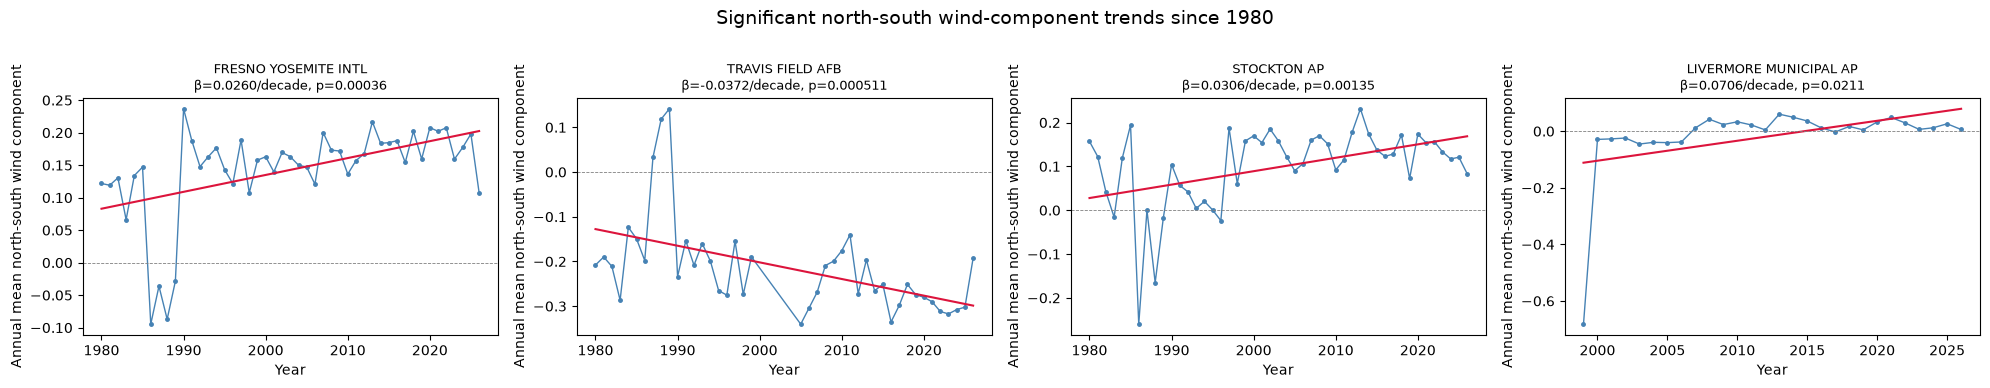

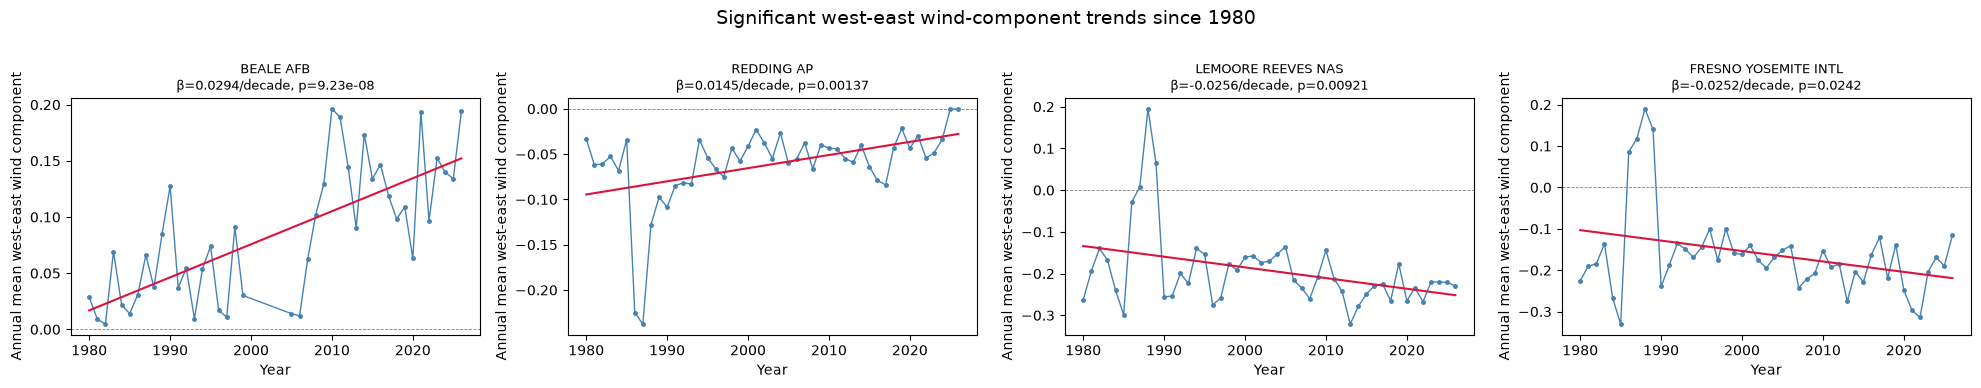

In [80]:
# Trend analysis of annual mean wind components since 1980
# north is positive, south is negative; east is positive, west is negative

# 1) Build annual station means
# filter to years since 1980
wind_since_1980 = CV_rows[CV_rows["year"] >= 1980].copy()

# compute annual mean wind components and number of observations per station
annual_wind = (
    # starting from 
    wind_since_1980
    # group by station and year to compute annual mean wind components and number of observations
    .groupby(["STATION", "year"], as_index=False)
    # aggregate to compute mean north-south and west-east wind components and number of observations
    .agg(
        # compute mean north-south and west-east wind components and number of observations
        ns_mean=("wind_ns_component", "mean"),
        # compute mean west-east wind component
        we_mean=("wind_we_component", "mean"),
        # compute number of observations for each station-year
        n_obs=("wind_ns_component", "size"),
    )
)

# 2) Fit linear trends by station for each component
# set minimum number of years required for trend analysis
min_years = 10
# make an empty list to store trend results for each station and component
trend_rows = []

# loop through each station and component to fit linear regression and store results
for station, g in annual_wind.groupby("STATION"):
    # loop through each component (north-south and west-east) to fit linear regression
    for col, comp_name in [("ns_mean", "north_south"), ("we_mean", "west_east")]:
        # drop rows with missing values for the current component
        d = g[["year", col]].dropna()
        # skip stations with fewer than the minimum number of years of data for trend analysis
        if d["year"].nunique() < min_years:
            continue

        # Fit linear regression using scipy.stats.linregress
        # set x and y values for the regression
        x = d["year"].to_numpy()
        y = d[col].to_numpy()
        # fit the linear regression model to the data and store the results
        fit = stats.linregress(x, y)

        # store the trend results for the current station and component in the trend_rows list
        trend_rows.append({
            # store the station name
            "STATION": station,
            # component name (north-south or west-east)
            "component": comp_name,
            # store the number of years of data used for the trend analysis
            "n_years": int(d["year"].nunique()),
            # store the slope of the trend per year
            "slope_per_year": fit.slope,
            # store the slope of the trend per decade (slope_per_year * 10)
            "slope_per_decade": fit.slope * 10,
            # store the intercept of the trend line
            "intercept": fit.intercept,
            # store the r-value of the trend
            "r_value": fit.rvalue,
            # store the r-squared value of the trend (r_value squared)
            "r_squared": fit.rvalue ** 2,
            # store the p-value of the trend
            "p_value": fit.pvalue,
            # store the standard error of the trend
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
trend_df = pd.DataFrame(trend_rows)
# filter for significant trends (p < 0.05)
sig_trends = trend_df[trend_df["p_value"] < 0.05].copy()

# print the total number of station-component trends tested and the number of significant trends (p < 0.05)
print(f"Total station-component trends tested: {len(trend_df)}")
# print the number of significant trends (p < 0.05)
print(f"Significant trends (p < 0.05): {len(sig_trends)}")
# display the top 20 significant trends sorted by component and p-value
print(sig_trends.sort_values(["component", "p_value"]).head(20))

# 3) Plot significant trends for each component
# loop through each component (north-south and west-east) to plot significant trends
for comp_name, col, ylab in [
    # define the component name, column name, and y-axis label
    # for north-south components
    ("north_south", "ns_mean", "Annual mean north-south wind component"),
    # for west-east components
    ("west_east", "we_mean", "Annual mean west-east wind component"),
]:
    # filter the significant trends DataFrame for the current component and sort by p-value
    sig_comp = sig_trends[sig_trends["component"] == comp_name].sort_values("p_value")
    # get the list of stations with significant trends for the current component
    stations = sig_comp["STATION"].tolist()

# check if there are any significant trends for the current component jic
    if len(stations) == 0:
        print(f"No significant {comp_name} trends found.")
        continue

    # set up the subplots for plotting significant trends for each station
    ncols = 4
    nrows = int(np.ceil(len(stations) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

# Loop through each station and plot the annual mean wind component and the fitted trend line
    for i, station in enumerate(stations):
        ax = axes[i]
        d = annual_wind[annual_wind["STATION"] == station][["year", col]].dropna().sort_values("year")
        t = sig_comp[sig_comp["STATION"] == station].iloc[0]

        ax.plot(d["year"], d[col], marker="o", linewidth=1, markersize=2.5, color="steelblue")
        ax.plot(
            d["year"],
            t["intercept"] + t["slope_per_year"] * d["year"],
            color="crimson",
            linewidth=1.5
        )
        ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
        ax.set_title(
            f"{station}\nβ={t['slope_per_decade']:.4f}/decade, p={t['p_value']:.3g}",
            fontsize=9
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylab)

    for j in range(len(stations), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Significant {comp_name.replace('_', '-') } wind-component trends since 1980", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [81]:
# Redefine valley axes by latitude and classify winds on along-/cross-valley axes
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

# Numeric wind fields
wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind blows toward)
wd_to = (wd + 180.0) % 360.0

# Latitude-dependent up-valley axis:
#   >= 38°N -> 330°
#   <  38°N -> 150°
# this means setting up-valley to be positive along 330° for stations north of 38°N
# up-valley will be positive along 150° for stations south of 38°N
CV_rows["up_valley_angle_lat"] = np.where(CV_rows["LATITUDE"] >= 38.0, 330.0, 150.0)

# Along-valley alignment (signed, unitless): +up-valley, -down-valley
delta_along = np.deg2rad(wd_to - CV_rows["up_valley_angle_lat"])
CV_rows["valley_along_component_lat"] = np.cos(delta_along)

# Cross-valley axis fixed as perpendicular to 330° (i.e., 60°)
cross_axis_330 = (valley_angle + 90.0) % 360.0
delta_cross = np.deg2rad(wd_to - cross_axis_330)
CV_rows["cross_valley_component_330"] = np.cos(delta_cross)

# Optional speed-weighted components
CV_rows["valley_along_component_lat_ws"] = CV_rows["valley_along_component_lat"] * ws
CV_rows["cross_valley_component_330_ws"] = CV_rows["cross_valley_component_330"] * ws

# Masks
missing_mask = wd.isna() | ws.isna()
calm_mask = wd.eq(0) | ws.eq(0)

# Along-axis classification (latitude-dependent valley axis)
CV_rows["valley_along_type_lat"] = np.select(
    [
        missing_mask,
        calm_mask,
        CV_rows["valley_along_component_lat"] > 0,
        CV_rows["valley_along_component_lat"] < 0,
    ],
    ["missing", "calm", "up_valley", "down_valley"],
    default="neutral"
)

# Cross-axis classification (perpendicular to 330° axis)
CV_rows["cross_valley_type_330"] = np.select(
    [
        missing_mask,
        calm_mask,
        CV_rows["cross_valley_component_330"] > 0,
        CV_rows["cross_valley_component_330"] < 0,
    ],
    ["missing", "calm", "cross_pos", "cross_neg"],
    default="neutral"
)

# Combined category on the two axes
CV_rows["wind_axis_category"] = np.where(
    missing_mask, "missing",
    np.where(
        calm_mask, "calm",
        CV_rows["valley_along_type_lat"] + "__" + CV_rows["cross_valley_type_330"]
    )
)

# Quick check
display(
    CV_rows[
        [
            "STATION", "LATITUDE", "HourlyWindDirection", "HourlyWindSpeed",
            "up_valley_angle_lat", "valley_along_component_lat", "cross_valley_component_330",
            "valley_along_type_lat", "cross_valley_type_330", "wind_axis_category"
        ]
    ].head(12)
)

display(CV_rows["wind_axis_category"].value_counts(dropna=False).head(20))

,STATION,LATITUDE,HourlyWindDirection,HourlyWindSpeed,up_valley_angle_lat,valley_along_component_lat,cross_valley_component_330,valley_along_type_lat,cross_valley_type_330,wind_axis_category
0,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
1,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
2,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
3,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
4,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
5,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
6,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
7,FRESNO YOSEMITE INTL,36.78,315.0,1.0,150.0,0.965926,0.258819,up_valley,cross_pos,up_valley__cross_pos
8,FRESNO YOSEMITE INTL,36.78,45.0,1.0,150.0,0.258819,-0.965926,up_valley,cross_neg,up_valley__cross_neg
9,FRESNO YOSEMITE INTL,36.78,45.0,1.0,150.0,0.258819,-0.965926,up_valley,cross_neg,up_valley__cross_neg


wind_axis_category
up_valley__cross_pos      2894887
calm                      1524398
up_valley__cross_neg      1430540
down_valley__cross_neg    1216260
down_valley__cross_pos    1155009
Name: count, dtype: int64

                   STATION    component  n_years  slope_pct_per_year  slope_pct_per_decade  r_squared  p_value  significant
            BAKERSFIELD AP cross_valley       47            0.000000              0.000000        NaN      NaN        False
                 BEALE AFB cross_valley       42            0.000000              0.000000        NaN      NaN        False
                CASTLE AFB cross_valley       30            0.000000              0.000000        NaN      NaN        False
      FRESNO YOSEMITE INTL cross_valley       47            0.000000              0.000000        NaN      NaN        False
        LEMOORE REEVES NAS cross_valley       47            0.000000              0.000000        NaN      NaN        False
    LIVERMORE MUNICIPAL AP cross_valley       28            0.000000              0.000000        NaN      NaN        False
         RED BLUFF MUNI AP cross_valley       46            0.000000              0.000000        NaN      NaN        False
        

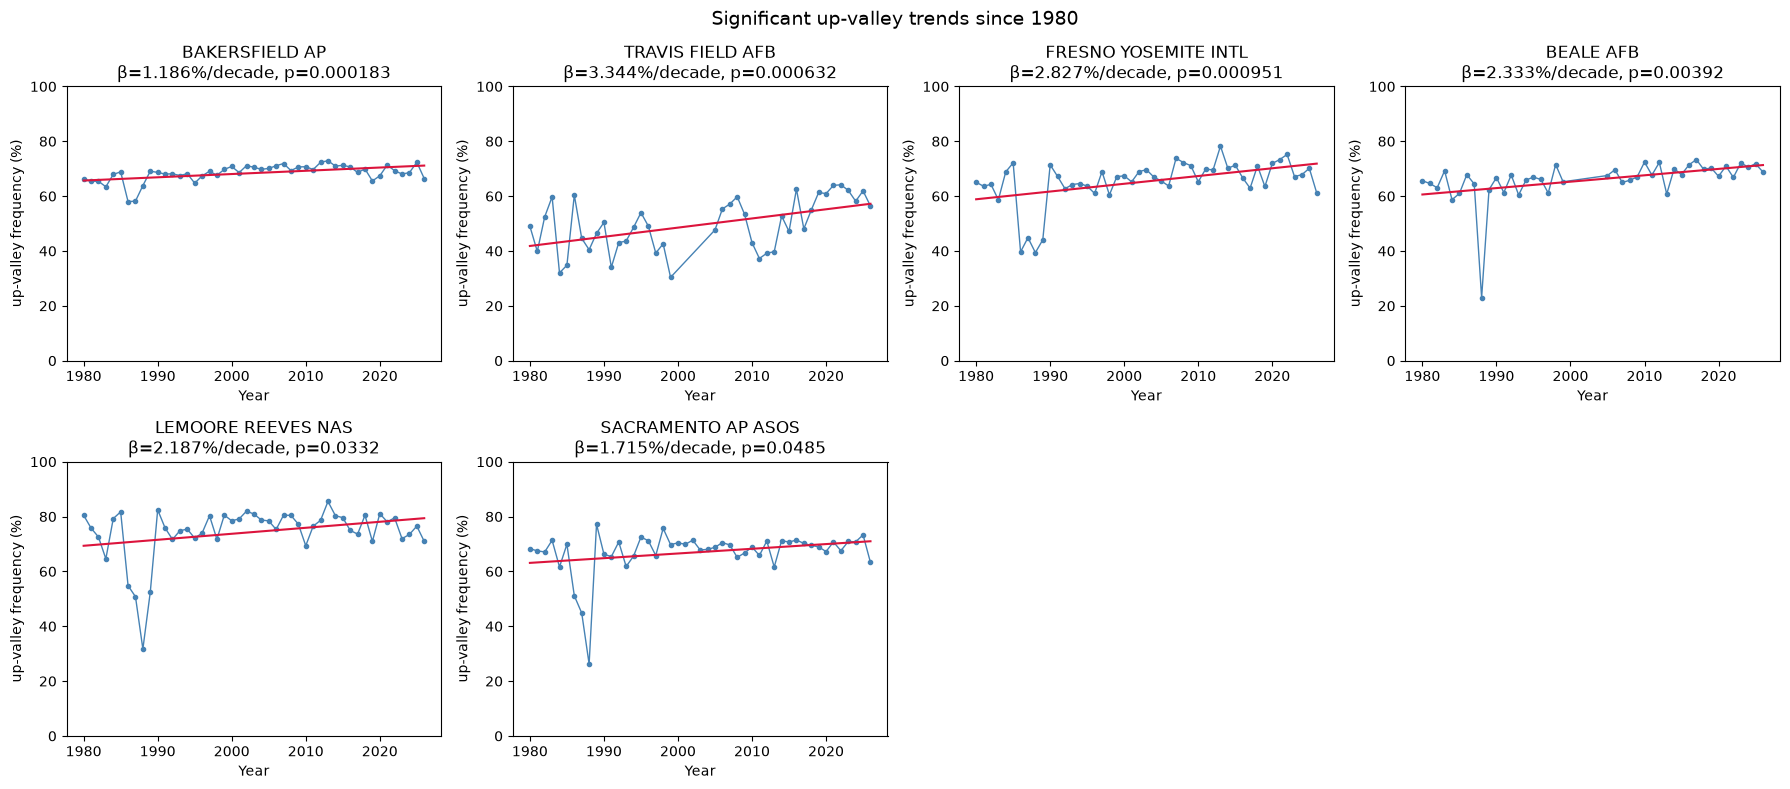

No significant cross-valley trends found.


In [82]:
# Annual up-valley and cross-valley frequency trends since 1980

trend_data = CV_rows.loc[CV_rows["year"] >= 1980].copy()

# Use non-calm, non-missing observations as the denominator
valid_wind = (
    ~trend_data["valley_along_type_lat"].isin(["calm", "missing"])
    & ~trend_data["cross_valley_type_330"].isin(["calm", "missing"])
)
trend_data = trend_data[valid_wind].copy()

# Define mutually independent indicators:
# up-valley = positive along-valley component
# cross-valley = either cross-valley direction
trend_data["up_valley"] = (
    trend_data["valley_along_type_lat"] == "up_valley"
).astype(int)

trend_data["cross_valley"] = (
    trend_data["cross_valley_type_330"].isin(["cross_pos", "cross_neg"])
).astype(int)

# Calculate annual percentages by station
annual_axis_freq = (
    trend_data
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        up_valley_pct=("up_valley", lambda x: 100 * x.mean()),
        cross_valley_pct=("cross_valley", lambda x: 100 * x.mean()),
        n_obs=("up_valley", "size"),
    )
)

# Fit linear trends
axis_trend_rows = []

for station, group in annual_axis_freq.groupby("STATION"):
    for component in ["up_valley_pct", "cross_valley_pct"]:
        d = group[["year", component]].dropna()

        if d["year"].nunique() < 10:
            continue

        fit = stats.linregress(d["year"], d[component])

        axis_trend_rows.append({
            "STATION": station,
            "component": component.replace("_pct", ""),
            "n_years": d["year"].nunique(),
            "slope_pct_per_year": fit.slope,
            "slope_pct_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

axis_trends = pd.DataFrame(axis_trend_rows)
axis_trends["significant"] = axis_trends["p_value"] < 0.05

print(axis_trends.sort_values(["component", "p_value"]).to_string(index=False))

# Plot significant trends
for component in ["up_valley", "cross_valley"]:
    sig = axis_trends[
        (axis_trends["component"] == component)
        & axis_trends["significant"]
    ].sort_values("p_value")

    if sig.empty:
        print(f"No significant {component.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(18, 4 * nrows), squeeze=False
    )
    axes = axes.ravel()

    value_col = f"{component}_pct"

    for ax, (_, result) in zip(axes, sig.iterrows()):
        station_data = annual_axis_freq[
            annual_axis_freq["STATION"] == result["STATION"]
        ].sort_values("year")

        ax.plot(
            station_data["year"],
            station_data[value_col],
            marker="o",
            markersize=3,
            linewidth=1,
            color="steelblue",
        )

        ax.plot(
            station_data["year"],
            result["slope_pct_per_year"] * station_data["year"]
            + (
                station_data[value_col].mean()
                - result["slope_pct_per_year"] * station_data["year"].mean()
            ),
            color="crimson",
            linewidth=1.5,
        )

        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_pct_per_decade']:.3f}%/decade, "
            f"p={result['p_value']:.3g}"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{component.replace('_', '-')} frequency (%)")
        ax.set_ylim(0, 100)

    for ax in axes[len(sig):]:
        ax.remove()

    fig.suptitle(
        f"Significant {component.replace('_', '-')} trends since 1980",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

In [83]:
# Up-/down-valley trend analysis for fog events only (HourlyVisibility < 1.0) since 1980

# Start from low-visibility event table built earlier
fog_ev = low_vis_events.copy()

# # Ensure datetime
# if not pd.api.types.is_datetime64_any_dtype(fog_ev["DATE"]):
#     fog_ev["DATE"] = pd.to_datetime(fog_ev["DATE"], errors="coerce")

# Recompute valley alignment on fog-event observations
wd_fog = pd.to_numeric(fog_ev["HourlyWindDirection"], errors="coerce")
ws_fog = pd.to_numeric(fog_ev["HourlyWindSpeed"], errors="coerce")
# wd_to_fog is the wind direction plus 180 degrees, representing the direction the wind is blowing toward
# wrapped to 360 degrees meaning that 0° and 360° are equivalent
wd_to_fog = (wd_fog + 180.0) % 360.0
alignment_fog = np.cos(np.deg2rad(wd_to_fog - valley_angle))

# Classify each fog-event observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
fog_ev["obs_valley_type"] = np.select(
    [
        wd_fog.isna() | ws_fog.isna(),
        wd_fog.eq(0) | ws_fog.eq(0),
        alignment_fog > 0,
        alignment_fog < 0,
    ],
    ["missing", "calm", "up_valley", "down_valley"],
    default="cross_valley",
)

# Keep years since 1980
fog_ev = fog_ev[fog_ev["year"] >= 1980].copy()

# Classify each event by dominant valley direction (up vs down)
event_type = (
    fog_ev[fog_ev["obs_valley_type"].isin(["up_valley", "down_valley"])]
    .groupby(["STATION", "event_id", "year", "obs_valley_type"], as_index=False)
    .size()
    .pivot_table(
        index=["STATION", "event_id", "year"],
        columns="obs_valley_type",
        values="size",
        fill_value=0
    )
    .reset_index()
)

# Ensure that both "up_valley" and "down_valley" columns exist in the event_type DataFrame
for c in ["up_valley", "down_valley"]:
    if c not in event_type.columns:
        event_type[c] = 0

# Classify each event as "up_valley", "down_valley", or "tie" based on the counts of up-valley and down-valley observations
event_type["event_wind_type"] = np.select(
    [event_type["up_valley"] > event_type["down_valley"],
     event_type["down_valley"] > event_type["up_valley"]],
    ["up_valley", "down_valley"],
    default="tie"
)

event_type = event_type[event_type["event_wind_type"].isin(["up_valley", "down_valley"])].copy()

# Annual event counts and percentages by station
annual_fog_event_valley = (
    event_type
    .groupby(["STATION", "year", "event_wind_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

# compute total events per station-year
annual_fog_event_valley["total"] = annual_fog_event_valley.groupby(["STATION", "year"])["count"].transform("sum")
# computer percentage of each wind type per station-year
annual_fog_event_valley["pct"] = 100 * annual_fog_event_valley["count"] / annual_fog_event_valley["total"]

# Trend fitting
fog_event_trend_rows = []
min_years = 1

# loop through each station and wind type to fit linear regression and store results
for station, g in annual_fog_event_valley.groupby("STATION"):
    for wind_type in ["up_valley", "down_valley"]:
        d = g[g["event_wind_type"] == wind_type][["year", "pct"]].dropna()
        if d["year"].nunique() < min_years:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d["pct"].to_numpy())
        fog_event_trend_rows.append({
            "STATION": station,
            "wind_type": wind_type,
            "n_years": int(d["year"].nunique()),
            "slope_per_year_pct": fit.slope,
            "slope_per_decade_pct": fit.slope * 10,
            "intercept": fit.intercept,
            "r_value": fit.rvalue,
            "r_squared": fit.rvalue**2,
            "p_value": fit.pvalue,
            "std_err": fit.stderr,
        })

# create a DataFrame from the trend results and filter for significant trends (p < 0.05)
fog_event_valley_trend_df = pd.DataFrame(fog_event_trend_rows)
fog_event_valley_sig_trends = fog_event_valley_trend_df[fog_event_valley_trend_df["p_value"] < 0.05].copy()

# print the number of total trends tested and significant trends found
print(f"Total fog-event station-category trends tested: {len(fog_event_valley_trend_df)}")
print(f"Significant fog-event trends (p < 0.05): {len(fog_event_valley_sig_trends)}")
print(fog_event_valley_sig_trends.sort_values(["wind_type", "p_value"]).head(20))

Total fog-event station-category trends tested: 28
Significant fog-event trends (p < 0.05): 1
               STATION    wind_type  n_years  slope_per_year_pct  \
17  SACRAMENTO AP ASOS  down_valley       40            0.637454   

    slope_per_decade_pct    intercept   r_value  r_squared   p_value   std_err  
17              6.374541 -1225.802685  0.380042   0.144432  0.015567  0.251682  


Station-category trends tested: 28
Significant trends (p < 0.05): 4


,STATION,category,n_years,slope_pct_per_year,slope_pct_per_decade,intercept,r_squared,p_value
13,RED BLUFF MUNI AP,cross_valley,31,0.384040,3.840398,-744.418569,0.174990,0.019184
24,STOCKTON AP,up_valley,39,0.365140,3.651397,-712.219644,0.175641,0.007917
2,BEALE AFB,up_valley,21,-0.449387,-4.493868,930.349224,0.235589,0.025719
0,BAKERSFIELD AP,up_valley,39,0.389535,3.895346,-743.492417,0.100264,0.049534


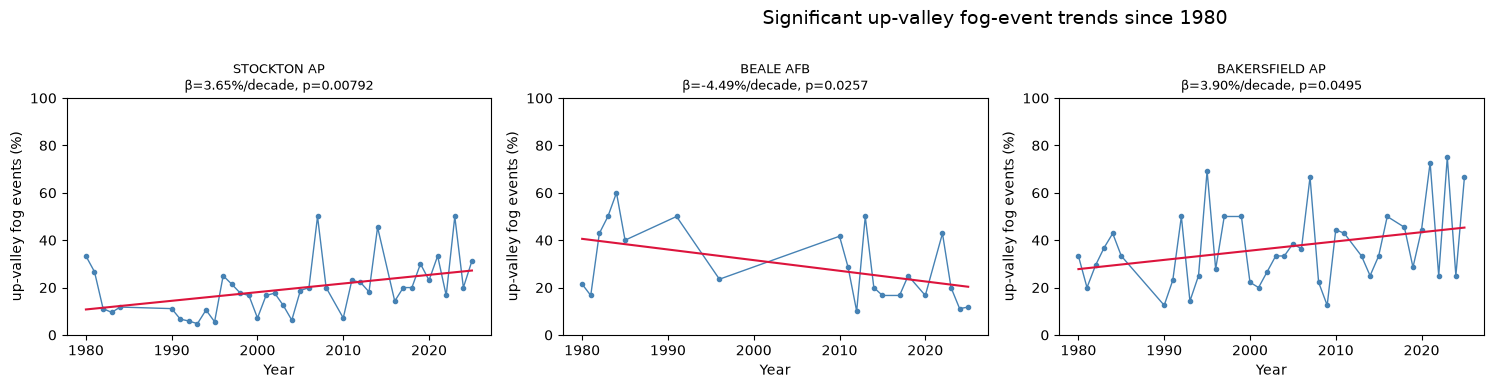

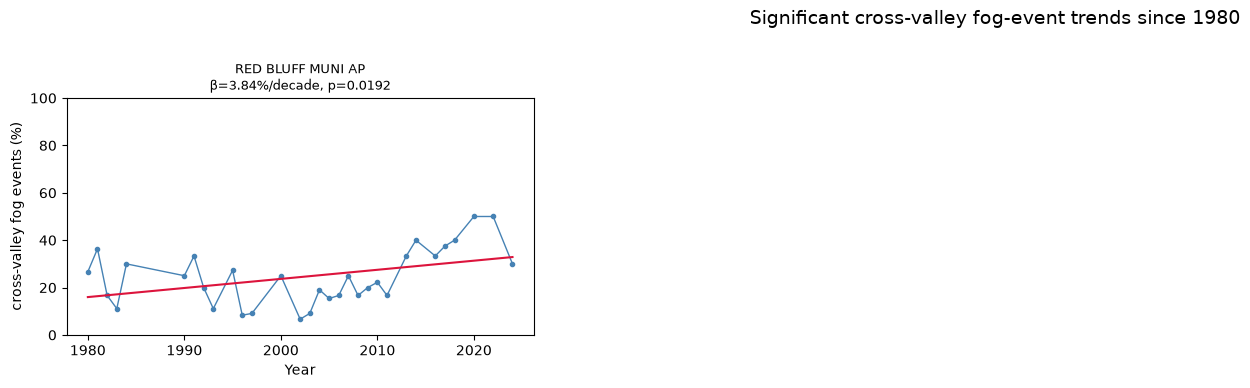

In [84]:
# Analyze significant up-valley and cross-valley trends for low-visibility fog events since 1980
# positive cross valley values are to the west, negative cross valley values are to the east
fog_axis = low_vis_events[low_vis_events["year"] >= 1980].copy()

wd_fog = pd.to_numeric(fog_axis["HourlyWindDirection"], errors="coerce")
ws_fog = pd.to_numeric(fog_axis["HourlyWindSpeed"], errors="coerce")
wd_to_fog = (wd_fog + 180.0) % 360.0

# Use the latitude-dependent up-valley axis defined for the full station dataset
fog_axis["up_valley_angle"] = np.where(fog_axis["LATITUDE"] >= 38.0, 330.0, 150.0)
fog_axis["along_component"] = np.cos(
    np.deg2rad(wd_to_fog - fog_axis["up_valley_angle"])
)

# Cross-valley axis is perpendicular to the local along-valley axis
fog_axis["cross_component"] = np.sin(
    np.deg2rad(wd_to_fog - fog_axis["up_valley_angle"])
)

valid_fog_wind = wd_fog.notna() & ws_fog.notna() & wd_fog.ne(0) & ws_fog.ne(0)
along_dominant = fog_axis["along_component"].abs() >= fog_axis["cross_component"].abs()

# Assign each fog observation to one mutually exclusive dominant wind category
fog_axis["fog_wind_category"] = np.select(
    [
        valid_fog_wind & along_dominant & (fog_axis["along_component"] > 0),
        valid_fog_wind & along_dominant & (fog_axis["along_component"] < 0),
        valid_fog_wind & ~along_dominant,
    ],
    ["up_valley", "down_valley", "cross_valley"],
    default="unclassified",
)

# Classify each event by its most frequent observation-level category
event_axis_counts = (
    fog_axis[fog_axis["fog_wind_category"] != "unclassified"]
    .groupby(["STATION", "event_id", "year", "fog_wind_category"], as_index=False)
    .size()
    .rename(columns={"size": "n_observations"})
)

event_axis_type = (
    event_axis_counts
    .sort_values(
        ["STATION", "event_id", "year", "n_observations", "fog_wind_category"],
        ascending=[True, True, True, False, True],
    )
    .drop_duplicates(["STATION", "event_id", "year"])
    .rename(columns={"fog_wind_category": "event_wind_category"})
)

# Annual percentages of events in each category
annual_fog_axis = (
    event_axis_type
    .groupby(["STATION", "year", "event_wind_category"], as_index=False)
    .size()
    .rename(columns={"size": "event_count"})
)

annual_fog_axis["total_events"] = annual_fog_axis.groupby(
    ["STATION", "year"]
)["event_count"].transform("sum")

annual_fog_axis["pct"] = (
    100 * annual_fog_axis["event_count"] / annual_fog_axis["total_events"]
)

# Fit station-level trends for up-valley and cross-valley event percentages
fog_axis_trend_rows = []

for station, group in annual_fog_axis.groupby("STATION"):
    for category in ["up_valley", "cross_valley"]:
        d = group.loc[
            group["event_wind_category"] == category, ["year", "pct"]
        ].dropna()

        if d["year"].nunique() < 10:
            continue

        fit = stats.linregress(d["year"], d["pct"])

        fog_axis_trend_rows.append(
            {
                "STATION": station,
                "category": category,
                "n_years": d["year"].nunique(),
                "slope_pct_per_year": fit.slope,
                "slope_pct_per_decade": fit.slope * 10,
                "intercept": fit.intercept,
                "r_squared": fit.rvalue**2,
                "p_value": fit.pvalue,
            }
        )

fog_axis_trends = pd.DataFrame(fog_axis_trend_rows)
fog_axis_sig_trends = fog_axis_trends[
    fog_axis_trends["p_value"] < 0.05
].copy()

print(f"Station-category trends tested: {len(fog_axis_trends)}")
print(f"Significant trends (p < 0.05): {len(fog_axis_sig_trends)}")
display(fog_axis_sig_trends.sort_values(["category", "p_value"]))

# Plot significant station trends
for category in ["up_valley", "cross_valley"]:
    sig = fog_axis_sig_trends[
        fog_axis_sig_trends["category"] == category
    ].sort_values("p_value")

    if sig.empty:
        print(f"No significant {category.replace('_', '-')} fog-event trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows))
    axes = np.asarray(axes).ravel()

    for ax, (_, result) in zip(axes, sig.iterrows()):
        d = annual_fog_axis[
            (annual_fog_axis["STATION"] == result["STATION"])
            & (annual_fog_axis["event_wind_category"] == category)
        ].sort_values("year")

        ax.plot(d["year"], d["pct"], marker="o", markersize=3, linewidth=1,
                color="steelblue")
        ax.plot(
            d["year"],
            result["intercept"] + result["slope_pct_per_year"] * d["year"],
            color="crimson",
            linewidth=1.5,
        )
        ax.set_title(
            f"{result['STATION']}\n"
            f"β={result['slope_pct_per_decade']:.2f}%/decade, "
            f"p={result['p_value']:.3g}",
            fontsize=9,
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{category.replace('_', '-')} fog events (%)")
        ax.set_ylim(0, 100)

    for ax in axes[len(sig):]:
        fig.delaxes(ax)

    fig.suptitle(
        f"Significant {category.replace('_', '-')} fog-event trends since 1980",
        fontsize=14,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

                   STATION component  start_year  end_year  n_years  slope_pct_per_year  slope_pct_per_decade  r_squared  p_value  significant
            BAKERSFIELD AP up_valley        1928      2026       99            0.104739              1.047388   0.206777 0.000002         True
      FRESNO YOSEMITE INTL up_valley        1941      2026       83            0.114069              1.140690   0.136641 0.000583         True
SACRAMENTO METROPOLITAN AP up_valley        1972      2026       52            0.330061              3.300608   0.135528 0.007249         True
                 BEALE AFB up_valley        1959      2026       62            0.219436              2.194363   0.105419 0.010033         True
        SACRAMENTO AP ASOS up_valley        1931      2026       96            0.051475              0.514747   0.044300 0.039557         True
        LEMOORE REEVES NAS up_valley        1961      2026       66            0.123153              1.231527   0.040345 0.105844        False

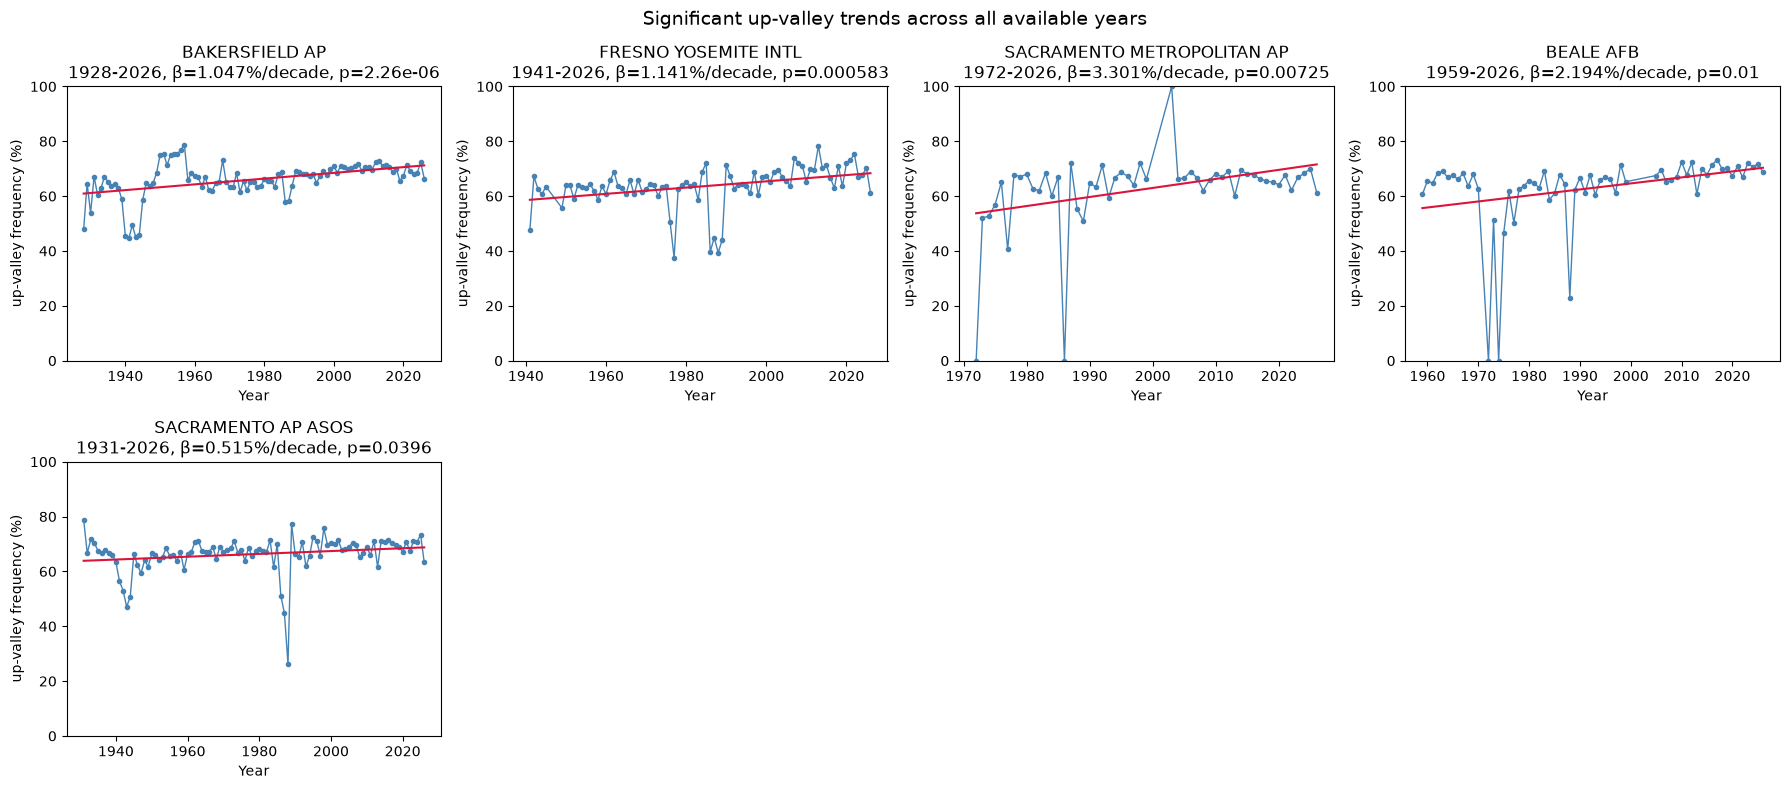

No significant all-years cross-valley trends found.


In [85]:
# Annual up-valley and cross-valley frequency trends using all available years

all_years_data = CV_rows.copy()

# Exclude calm and missing observations from the denominator
valid_all_years = (
    ~all_years_data["valley_along_type_lat"].isin(["calm", "missing"])
    & ~all_years_data["cross_valley_type_330"].isin(["calm", "missing"])
)
all_years_data = all_years_data.loc[valid_all_years].copy()

# Define indicators
all_years_data["up_valley"] = (
    all_years_data["valley_along_type_lat"] == "up_valley"
).astype(int)

all_years_data["cross_valley"] = (
    all_years_data["cross_valley_type_330"].isin(["cross_pos", "cross_neg"])
).astype(int)

# Calculate annual frequencies by station
annual_axis_freq_all_years = (
    all_years_data
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        up_valley_pct=("up_valley", lambda x: 100 * x.mean()),
        cross_valley_pct=("cross_valley", lambda x: 100 * x.mean()),
        n_obs=("up_valley", "size"),
    )
)

# Fit linear trends
axis_trend_rows_all_years = []

for station, group in annual_axis_freq_all_years.groupby("STATION"):
    for component in ["up_valley_pct", "cross_valley_pct"]:
        d = group[["year", component]].dropna()

        if d["year"].nunique() < 10 or d[component].nunique() < 2:
            continue

        fit = stats.linregress(d["year"], d[component])

        axis_trend_rows_all_years.append({
            "STATION": station,
            "component": component.replace("_pct", ""),
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_pct_per_year": fit.slope,
            "slope_pct_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

axis_trends_all_years = pd.DataFrame(axis_trend_rows_all_years)
axis_trends_all_years["significant"] = (
    axis_trends_all_years["p_value"] < 0.05
)

print(axis_trends_all_years.sort_values(
    ["component", "p_value"]
).to_string(index=False))

# Plot significant trends
for component in ["up_valley", "cross_valley"]:
    sig = axis_trends_all_years[
        (axis_trends_all_years["component"] == component)
        & axis_trends_all_years["significant"]
    ].sort_values("p_value")

    if sig.empty:
        print(f"No significant all-years {component.replace('_', '-')} trends found.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(18, 4 * nrows), squeeze=False
    )
    axes = axes.ravel()

    value_col = f"{component}_pct"

    for ax, (_, result) in zip(axes, sig.iterrows()):
        station_data = annual_axis_freq_all_years[
            annual_axis_freq_all_years["STATION"] == result["STATION"]
        ].sort_values("year")

        trend_line = (
            result["slope_pct_per_year"] * station_data["year"]
            + (
                station_data[value_col].mean()
                - result["slope_pct_per_year"] * station_data["year"].mean()
            )
        )

        ax.plot(
            station_data["year"],
            station_data[value_col],
            marker="o",
            markersize=3,
            linewidth=1,
            color="steelblue",
        )
        ax.plot(
            station_data["year"],
            trend_line,
            color="crimson",
            linewidth=1.5,
        )

        ax.set_title(
            f"{result['STATION']}\n"
            f"{result['start_year']}-{result['end_year']}, "
            f"β={result['slope_pct_per_decade']:.3f}%/decade, "
            f"p={result['p_value']:.3g}"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{component.replace('_', '-')} frequency (%)")
        ax.set_ylim(0, 100)

    for ax in axes[len(sig):]:
        fig.delaxes(ax)

    fig.suptitle(
        f"Significant {component.replace('_', '-')} trends across all available years",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

Annual station-year rows before outlier exclusion: 999
Rows remaining after outlier exclusion: 900

All-years trends after outlier exclusion:
                   STATION component  start_year  end_year  n_years  slope_pct_per_year  slope_pct_per_decade  r_squared      p_value  significant
      FRESNO YOSEMITE INTL up_valley        1942      2026       75            0.094269              0.942686   0.339015 4.266011e-08         True
                 BEALE AFB up_valley        1959      2026       56            0.082886              0.828860   0.227046 2.053452e-04         True
        SACRAMENTO AP ASOS up_valley        1932      2026       87            0.040811              0.408106   0.135719 4.466812e-04         True
            BAKERSFIELD AP up_valley        1929      2026       92            0.044988              0.449876   0.087146 4.279908e-03         True
                CASTLE AFB up_valley        1942      2026       58            0.043238              0.432381   0.063628 5.

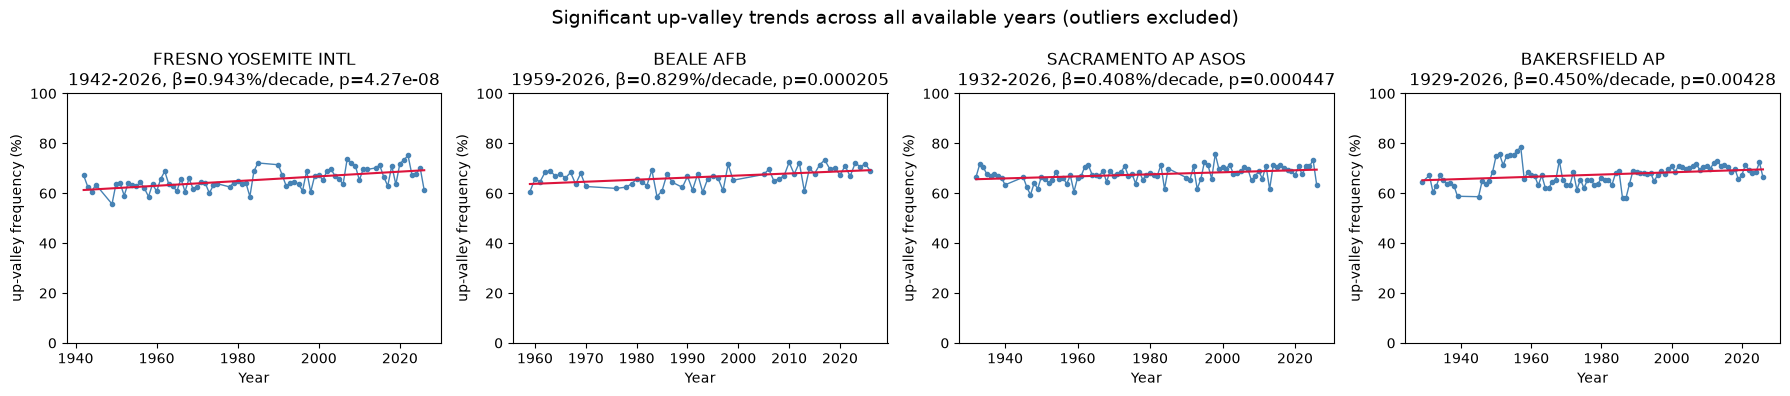


No significant cross-valley trends found after outlier exclusion.


In [86]:
# Exclude outliers and run all-years trend analysis for annual up-/cross-valley frequencies

# Rebuild annual frequency table from all available years
all_years_data = CV_rows.copy()

# Exclude calm and missing wind observations from the denominator
valid_all_years = (
    ~all_years_data["valley_along_type_lat"].isin(["calm", "missing"])
    & ~all_years_data["cross_valley_type_330"].isin(["calm", "missing"])
)
all_years_data = all_years_data.loc[valid_all_years].copy()

# Define indicators
all_years_data["up_valley"] = (
    all_years_data["valley_along_type_lat"] == "up_valley"
).astype(int)

all_years_data["cross_valley"] = (
    all_years_data["cross_valley_type_330"].isin(["cross_pos", "cross_neg"])
).astype(int)

# Annual percentages by station and year
annual_axis_freq_all_years = (
    all_years_data
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        up_valley_pct=("up_valley", lambda x: 100 * x.mean()),
        cross_valley_pct=("cross_valley", lambda x: 100 * x.mean()),
        n_obs=("up_valley", "size"),
    )
    .sort_values(["STATION", "year"])
)

# Exclude outliers within each station and component using the IQR rule
for component in ["up_valley_pct", "cross_valley_pct"]:
    q1 = annual_axis_freq_all_years.groupby("STATION")[component].transform("quantile", 0.25)
    q3 = annual_axis_freq_all_years.groupby("STATION")[component].transform("quantile", 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (
        (annual_axis_freq_all_years[component] < lower)
        | (annual_axis_freq_all_years[component] > upper)
    )
    annual_axis_freq_all_years[f"{component}_clean"] = np.where(
        outlier_mask, np.nan, annual_axis_freq_all_years[component]
    )

n_before = len(annual_axis_freq_all_years)
n_after = annual_axis_freq_all_years.dropna(subset=["up_valley_pct_clean", "cross_valley_pct_clean"]).shape[0]
print(f"Annual station-year rows before outlier exclusion: {n_before}")
print(f"Rows remaining after outlier exclusion: {n_after}")

# Fit linear trends using the cleaned annual values
axis_trend_rows_all_years = []
for station, group in annual_axis_freq_all_years.groupby("STATION"):
    for component in ["up_valley_pct", "cross_valley_pct"]:
        clean_col = f"{component}_clean"
        d = group[["year", clean_col]].dropna()
        if d["year"].nunique() < 10 or d[clean_col].nunique() < 2:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[clean_col].to_numpy())

        axis_trend_rows_all_years.append({
            "STATION": station,
            "component": component.replace("_pct", ""),
            "start_year": int(d["year"].min()),
            "end_year": int(d["year"].max()),
            "n_years": int(d["year"].nunique()),
            "slope_pct_per_year": fit.slope,
            "slope_pct_per_decade": fit.slope * 10,
            "r_squared": fit.rvalue ** 2,
            "p_value": fit.pvalue,
        })

axis_trends_all_years = pd.DataFrame(axis_trend_rows_all_years)
axis_trends_all_years["significant"] = axis_trends_all_years["p_value"] < 0.05

print("\nAll-years trends after outlier exclusion:")
print(axis_trends_all_years.sort_values(["component", "p_value"]).to_string(index=False))

# Plot significant trends
for component in ["up_valley", "cross_valley"]:
    sig = axis_trends_all_years[
        (axis_trends_all_years["component"] == component)
        & axis_trends_all_years["significant"]
    ].sort_values("p_value")

    if sig.empty:
        print(f"\nNo significant {component.replace('_', '-')} trends found after outlier exclusion.")
        continue

    ncols = 4
    nrows = int(np.ceil(len(sig) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), squeeze=False)
    axes = axes.ravel()

    value_col = f"{component}_pct_clean"

    for ax, (_, result) in zip(axes, sig.iterrows()):
        station_data = annual_axis_freq_all_years[
            annual_axis_freq_all_years["STATION"] == result["STATION"]
        ].sort_values("year").dropna(subset=[value_col])

        if station_data.empty:
            continue

        trend_line = (
            result["slope_pct_per_year"] * station_data["year"]
            + (
                station_data[value_col].mean()
                - result["slope_pct_per_year"] * station_data["year"].mean()
            )
        )

        ax.plot(
            station_data["year"],
            station_data[value_col],
            marker="o",
            markersize=3,
            linewidth=1,
            color="steelblue",
        )
        ax.plot(
            station_data["year"],
            trend_line,
            color="crimson",
            linewidth=1.5,
        )

        ax.set_title(
            f"{result['STATION']}\n"
            f"{result['start_year']}-{result['end_year']}, "
            f"β={result['slope_pct_per_decade']:.3f}%/decade, "
            f"p={result['p_value']:.3g}"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(f"{component.replace('_', '-')} frequency (%)")
        ax.set_ylim(0, 100)

    for ax in axes[len(sig):]:
        fig.delaxes(ax)

    fig.suptitle(
        f"Significant {component.replace('_', '-')} trends across all available years (outliers excluded)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

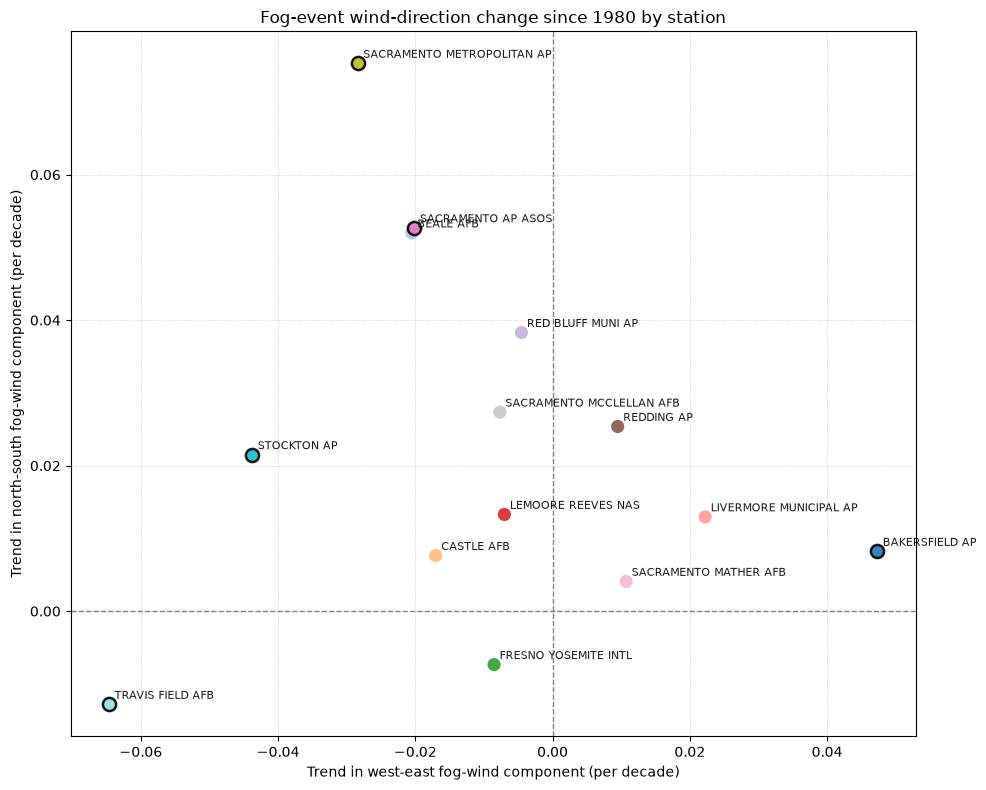

In [87]:
# Determine how wind direction has changed for fog events since 1980
# and plot each station on a single scatterplot with unique colors;
# significant station trends are outlined in black.

fog_wind = low_vis_events[low_vis_events["year"] >= 1980].copy()

# Rebuild wind vector components for fog-event observations
wd = pd.to_numeric(fog_wind["HourlyWindDirection"], errors="coerce")
fog_wind["wind_ns_component"] = np.where(
    wd.eq(0) | wd.isna(),
    0.0,
    np.cos(np.deg2rad(wd))
)
fog_wind["wind_we_component"] = np.where(
    wd.eq(0) | wd.isna(),
    0.0,
    np.sin(np.deg2rad(wd))
)

# Annual mean wind-vector components for each station
annual_fog_wind = (
    fog_wind
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        ns_mean=("wind_ns_component", "mean"),
        we_mean=("wind_we_component", "mean"),
        n_obs=("wind_ns_component", "size"),
    )
    .dropna(subset=["ns_mean", "we_mean"])
    .sort_values(["STATION", "year"])
)

# Fit linear trends for each station and component
trend_rows = []

for station, g in annual_fog_wind.groupby("STATION"):
    for col, component in [("ns_mean", "north_south"), ("we_mean", "west_east")]:
        d = g[["year", col]].dropna()
        if d["year"].nunique() < 10:
            continue

        fit = stats.linregress(d["year"].to_numpy(), d[col].to_numpy())
        trend_rows.append({
            "STATION": station,
            "component": component,
            "n_years": int(d["year"].nunique()),
            "slope_per_decade": fit.slope * 10,
            "p_value": fit.pvalue,
        })

fog_wind_trends = pd.DataFrame(trend_rows)

# Convert trend slopes to station-level plot coordinates
station_slopes = (
    fog_wind_trends
    .pivot(index="STATION", columns="component", values="slope_per_decade")
    .rename(columns={"north_south": "ns_slope_per_decade", "west_east": "we_slope_per_decade"})
)

station_p = (
    fog_wind_trends
    .pivot(index="STATION", columns="component", values="p_value")
    .rename(columns={"north_south": "ns_p", "west_east": "we_p"})
)

# A station is significant if either component has p < 0.05
station_sig = ((station_p["ns_p"] < 0.05) | (station_p["we_p"] < 0.05)).rename("significant")

station_plot = station_slopes.join(station_sig).dropna()

# Plot all stations together
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap("tab20", len(station_plot))

for i, (station, row) in enumerate(station_plot.iterrows()):
    is_sig = bool(row["significant"])
    ax.scatter(
        row["we_slope_per_decade"],
        row["ns_slope_per_decade"],
        s=90,
        color=cmap(i),
        edgecolors="black" if is_sig else "none",
        linewidths=1.8 if is_sig else 0.0,
        alpha=0.9,
        zorder=2
    )
    ax.annotate(
        station,
        (row["we_slope_per_decade"], row["ns_slope_per_decade"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        color="black",
        alpha=0.9,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

ax.set_xlabel("Trend in west-east fog-wind component (per decade)")
ax.set_ylabel("Trend in north-south fog-wind component (per decade)")
ax.set_title("Fog-event wind-direction change since 1980 by station")

plt.tight_layout()
plt.show()

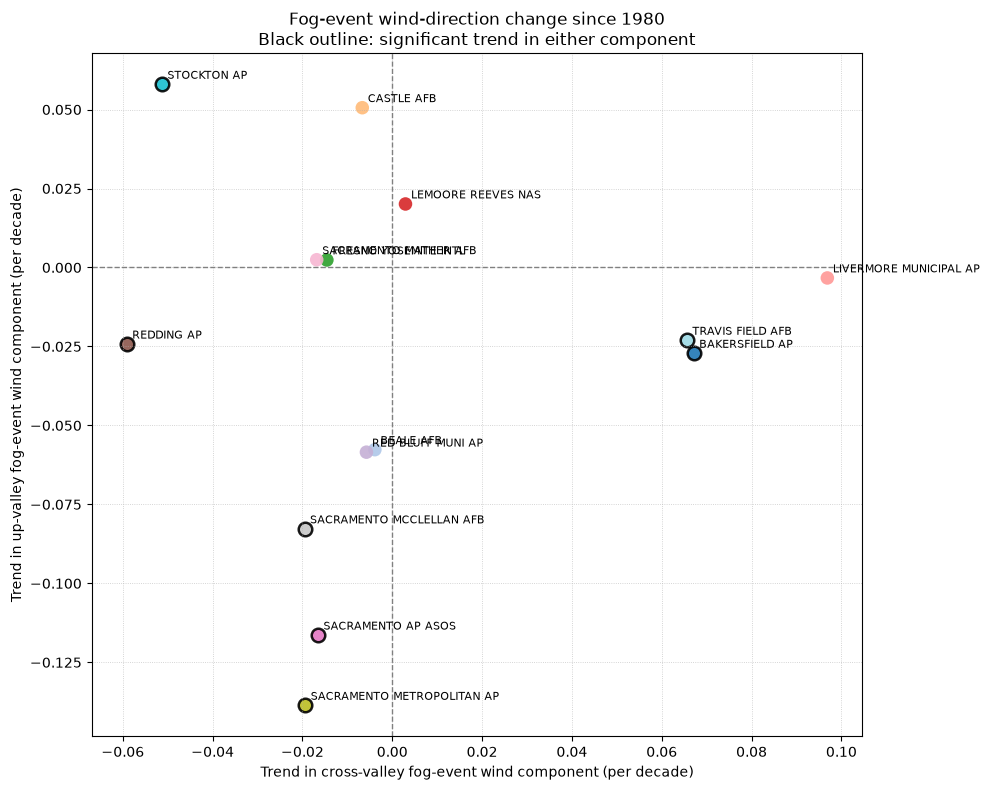

In [88]:
# Fog-event wind-direction trends using the latitude-dependent up-valley axis

fog_direction = low_vis_events.loc[
    low_vis_events["year"] >= 1980
].copy()

wd_fog_direction = pd.to_numeric(
    fog_direction["HourlyWindDirection"], errors="coerce"
)
ws_fog_direction = pd.to_numeric(
    fog_direction["HourlyWindSpeed"], errors="coerce"
)

# Convert wind-from direction to wind-toward direction
wd_to_fog_direction = (wd_fog_direction + 180) % 360

valid_fog_direction = (
    wd_fog_direction.notna()
    & ws_fog_direction.notna()
    & wd_fog_direction.ne(0)
    & ws_fog_direction.ne(0)
)

# Latitude-dependent up-valley direction
fog_direction["up_valley_angle"] = np.where(
    fog_direction["LATITUDE"] >= 38.0, 330.0, 150.0
)

angle_difference = np.deg2rad(
    wd_to_fog_direction - fog_direction["up_valley_angle"]
)

fog_direction["along_valley_component"] = np.cos(angle_difference)
fog_direction["cross_valley_component"] = np.sin(angle_difference)

# Exclude missing and calm winds
fog_direction.loc[
    ~valid_fog_direction,
    ["along_valley_component", "cross_valley_component"]
] = np.nan

# Annual station means
annual_fog_direction = (
    fog_direction
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        along_mean=("along_valley_component", "mean"),
        cross_mean=("cross_valley_component", "mean"),
        n_obs=("along_valley_component", "count"),
    )
)

# Fit station-level trends
fog_direction_trend_rows = []

for station, group in annual_fog_direction.groupby("STATION"):
    for component in ["along_mean", "cross_mean"]:
        d = group[["year", component]].dropna()

        if d["year"].nunique() < 10 or d[component].nunique() < 2:
            continue

        fit = stats.linregress(d["year"], d[component])

        fog_direction_trend_rows.append({
            "STATION": station,
            "component": component,
            "slope_per_decade": fit.slope * 10,
            "p_value": fit.pvalue,
        })

fog_direction_trends = pd.DataFrame(fog_direction_trend_rows)

# Convert to station-level plotting coordinates
fog_direction_slopes = (
    fog_direction_trends
    .pivot(index="STATION", columns="component", values="slope_per_decade")
    .rename(columns={
        "along_mean": "up_valley_slope_per_decade",
        "cross_mean": "cross_valley_slope_per_decade",
    })
)

fog_direction_p = (
    fog_direction_trends
    .pivot(index="STATION", columns="component", values="p_value")
    .rename(columns={
        "along_mean": "up_valley_p",
        "cross_mean": "cross_valley_p",
    })
)

fog_direction_plot = fog_direction_slopes.join(fog_direction_p).dropna()

fog_direction_plot["significant"] = (
    (fog_direction_plot["up_valley_p"] < 0.05)
    | (fog_direction_plot["cross_valley_p"] < 0.05)
)

# Plot all stations
fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.get_cmap("tab20", len(fog_direction_plot))

for i, (station, row) in enumerate(fog_direction_plot.iterrows()):
    ax.scatter(
        row["cross_valley_slope_per_decade"],
        row["up_valley_slope_per_decade"],
        s=95,
        color=cmap(i),
        edgecolors="black" if row["significant"] else "none",
        linewidths=1.8 if row["significant"] else 0,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["cross_valley_slope_per_decade"],
            row["up_valley_slope_per_decade"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

ax.set_xlabel(
    "Trend in cross-valley fog-event wind component "
    "(per decade)"
)
ax.set_ylabel(
    "Trend in up-valley fog-event wind component "
    "(per decade)"
)
ax.set_title(
    "Fog-event wind-direction change since 1980\n"
    "Black outline: significant trend in either component"
)

plt.tight_layout()
plt.show()

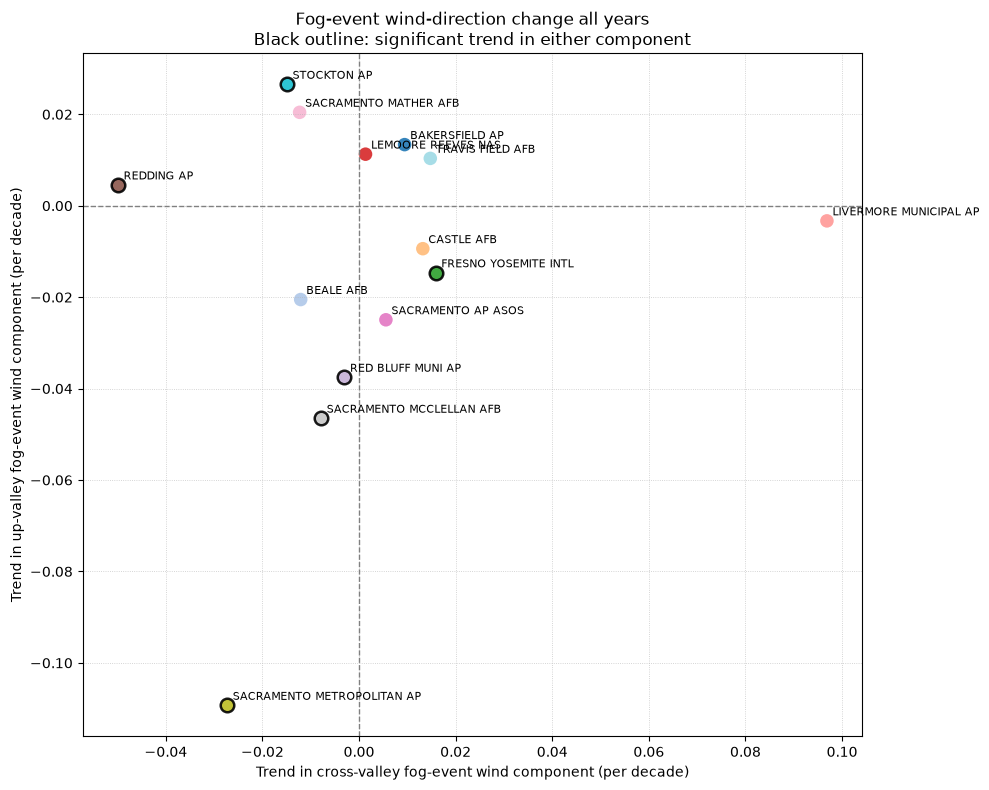

In [89]:
# Fog-event wind-direction trends using the latitude-dependent up-valley axis

fog_direction1 = low_vis_events.copy()

wd_fog_direction1 = pd.to_numeric(
    fog_direction1["HourlyWindDirection"], errors="coerce"
)
ws_fog_direction1 = pd.to_numeric(
    fog_direction1["HourlyWindSpeed"], errors="coerce"
)

# Convert wind-from direction to wind-toward direction
wd_to_fog_direction1 = (wd_fog_direction1 + 180) % 360

valid_fog_direction1 = (
    wd_fog_direction1.notna()
    & ws_fog_direction1.notna()
    & wd_fog_direction1.ne(0)
    & ws_fog_direction1.ne(0)
)

# Latitude-dependent up-valley direction
fog_direction1["up_valley_angle"] = np.where(
    fog_direction1["LATITUDE"] >= 38.0, 330.0, 150.0
)

angle_difference1 = np.deg2rad(
    wd_to_fog_direction1 - fog_direction1["up_valley_angle"]
)

fog_direction1["along_valley_component"] = np.cos(angle_difference1)
fog_direction1["cross_valley_component"] = np.sin(angle_difference1)

# Exclude missing and calm winds
fog_direction1.loc[
    ~valid_fog_direction1,
    ["along_valley_component", "cross_valley_component"]
] = np.nan

# Annual station means
annual_fog_direction = (
    fog_direction1
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        along_mean=("along_valley_component", "mean"),
        cross_mean=("cross_valley_component", "mean"),
        n_obs=("along_valley_component", "count"),
    )
)

# Fit station-level trends
fog_direction_trend_rows1 = []

for station, group in annual_fog_direction.groupby("STATION"):
    for component in ["along_mean", "cross_mean"]:
        d = group[["year", component]].dropna()

        if d["year"].nunique() < 10 or d[component].nunique() < 2:
            continue

        fit = stats.linregress(d["year"], d[component])

        fog_direction_trend_rows1.append({
            "STATION": station,
            "component": component,
            "slope_per_decade": fit.slope * 10,
            "p_value": fit.pvalue,
        })

fog_direction_trends1 = pd.DataFrame(fog_direction_trend_rows1)

# Convert to station-level plotting coordinates
fog_direction_slopes1 = (
    fog_direction_trends1
    .pivot(index="STATION", columns="component", values="slope_per_decade")
    .rename(columns={
        "along_mean": "up_valley_slope_per_decade",
        "cross_mean": "cross_valley_slope_per_decade",
    })
)

fog_direction_p1 = (
    fog_direction_trends1
    .pivot(index="STATION", columns="component", values="p_value")
    .rename(columns={
        "along_mean": "up_valley_p",
        "cross_mean": "cross_valley_p",
    })
)

fog_direction_plot1 = fog_direction_slopes1.join(fog_direction_p1).dropna()

fog_direction_plot1["significant"] = (
    (fog_direction_plot1["up_valley_p"] < 0.05)
    | (fog_direction_plot1["cross_valley_p"] < 0.05)
)

# Plot all stations
fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.get_cmap("tab20", len(fog_direction_plot1))

for i, (station, row) in enumerate(fog_direction_plot1.iterrows()):
    ax.scatter(
        row["cross_valley_slope_per_decade"],
        row["up_valley_slope_per_decade"],
        s=95,
        color=cmap(i),
        edgecolors="black" if row["significant"] else "none",
        linewidths=1.8 if row["significant"] else 0,
        alpha=0.9,
    )

    ax.annotate(
        station,
        (
            row["cross_valley_slope_per_decade"],
            row["up_valley_slope_per_decade"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)

ax.set_xlabel(
    "Trend in cross-valley fog-event wind component "
    "(per decade)"
)
ax.set_ylabel(
    "Trend in up-valley fog-event wind component "
    "(per decade)"
)
ax.set_title(
    "Fog-event wind-direction change all years\n"
    "Black outline: significant trend in either component"
)

plt.tight_layout()
plt.show()